In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit
from utilities_rbf import compute_relative_L2_error, local_orders, sampling_domain


@njit
def rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def drbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = -2.0 * b2 * r * np.exp(-b2 * r*r)
    return out




@njit
def rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.sqrt(1 + (b * r)**2)
    return out


@njit
def drbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (b*b * r) / np.sqrt(1.0 + (b*r)*(b*r))
    return out





@njit
def rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / np.sqrt(1 + (b * r)**2)
    return out


@njit
def drbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1.0 + (b*r)*(b*r))**1.5  # (3/2)
            out[i, j] = -(b*b * r) / denom
    return out



@njit
def rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / (1 + (b * r)**2)
    return out

@njit
def drbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1.0 + (b*r)*(b*r))**2
            out[i, j] = -2.0 * (b*b) * r / denom
    return out





# -------- Wendland C^2:  φ(s) = (1 - s)^4 (4s + 1),  s = b |x-c| ∈ [0,1] --------
@njit
def rbf_wendland_c2(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = (t**4) * (4.0*s + 1.0)
            else:
                out[i, j] = 0.0
    return out


@njit
def drbf_wendland_c2(x, c, b):
    # phi(s) = (1 - s)^4 (4s + 1),  0 <= s < 1
    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            s = b * abs(r)
            if s < 1.0:
                t = 1.0 - s
                # d/dx phi = -20 b^2 r (1 - s)^3
                out[i, j] = -20.0 * b2 * r * (t**3)
            else:
                out[i, j] = 0.0
    return out


# -------- Wendland C^4:  phi(s) = (1 - s)^6 (35 s^2 + 18 s + 3), s = b |x-c| in [0,1] --------
@njit
def rbf_wendland_c4(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                poly = 35.0*s*s + 18.0*s + 3.0
                out[i, j] = (t**6) * poly
            else:
                out[i, j] = 0.0
    return out



@njit
def drbf_wendland_c4(x, c, b):
    # phi(s) = (1 - s)^6 (35 s^2 + 18 s + 3),  0 <= s < 1
    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            s = b * abs(r)
            if s < 1.0:
                t = 1.0 - s
                # d/dx phi = -56 b^2 r (5 s + 1) (1 - s)^5
                out[i, j] = -56.0 * b2 * r * (5.0*s + 1.0) * (t**5)
            else:
                out[i, j] = 0.0
    return out



def solver_rbf(N, rbf_func, drbf_func, tau=1e-15, beta=3e5, zeta = 2,
               T = 8.0,lower_a = 0.0, upper_b = 1.0,
               sampling_choice = 'random',
               seed_value = 123456,sigma_scale_random = 0.001):
    M = zeta * N
    x_bdry = np.array([lower_a, upper_b]) 
    M_bdry = np.int64(x_bdry.size)
    M_int = M - M_bdry
    c_val = np.pi/(T * np.sqrt(2 * np.log(1 + tau**(-2))))
    b = c_val * N

    a1, a2 = -1.0, -1.5

    x_int = sampling_domain(M_int, a = lower_a, b = upper_b, 
                        mode = sampling_choice, 
                        seed = seed_value, 
                        jitter_frac = sigma_scale_random)

    x_plot = np.linspace(lower_a, upper_b, M) # full grid. 
    
    L = 0.5 * (upper_b -  lower_a)
    q = 0.5 * (lower_a  + upper_b) 
    centers = np.linspace(q - T * L, q + T * L, N)
    dx_int = x_int[1] - x_int[0]

    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    rhs_int = f(x_int)

    Phi_raw = rbf_func(x_int, centers, b)
    Phi_int = Phi_raw / np.sqrt(N)

    D1Phi_int = drbf_func(x_int, centers, b) / np.sqrt(N)
    A1 = D1Phi_int.T @ D1Phi_int * dx_int
    r_vec = Phi_int.T @ rhs_int * dx_int

    
    Phi_bdry = rbf_func(x_bdry, centers, b) / np.sqrt(N)
    g_bdry = u_true(x_bdry)

    A3 = np.sqrt(M_bdry) * Phi_bdry
    r3 = np.sqrt(M_bdry) * g_bdry

    A_total = A1 + beta * A3.T @ A3
    b_total = r_vec + beta * A3.T @ r3

    U, S, VT = svd(A_total)
    S_inv = np.where(S > tau * np.max(S), 1/S, 0)
    w_tau = VT.T @ (S_inv * (U.T @ b_total))
    
    Phi_plot = rbf_func(x_plot, centers, b) / np.sqrt(N)
    u_hat_tau = Phi_plot @ w_tau
    u_exact = u_true(x_plot)
    outputs = compute_relative_L2_error(u_hat_tau, u_exact, x_plot) 
    rel_l2_err = outputs['rel_L2_err']
    return rel_l2_err






# Plot
#fig, axs = plt.subplots(1, 1, figsize=(16, 8))

# Left: RBF type comparison
#markers = ['o', 's', 'd', '^']
#for i, (name, errs) in enumerate(errors_rbf.items()):
#    axs[0].plot(N_values, errs,'-',label=name, linewidth=4.5, marker=markers[i])
#axs[0].set_xticks(N_values)
#axs[0].set_yscale('log')
#axs[0].set_title(r'Radial Basis Function Comparison', fontsize=20)
#axs[0].set_xlabel(r'$N$: number of basis functions', fontsize=18)
#axs[0].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
#axs[0].tick_params(labelsize=16)
#axs[0].grid(True)
#axs[0].legend(fontsize=14)

# Right: Tau sensitivity for Gaussian
#for i, (tau, errs) in enumerate(errors_tau.items()):
#    axs[1].plot(N_values, errs,'-',label=fr"$\tau = {tau:.0e}$", linewidth=4.5, marker=markers[i % len(markers)])
#axs[1].set_xticks(N_values)
#axs[1].set_yscale('log')
#axs[1].set_title(r'Thresholding Value $\tau, \phi_{RBF} \coloneq Gaussian$', fontsize=20)
#axs[1].set_xlabel(r'$N$: number of basis functions', fontsize=18)
#axs[1].set_ylabel(r'Relative $L^2$ Error', fontsize=18)
#axs[1].tick_params(labelsize=16)
#axs[1].grid(True)
#axs[1].legend(fontsize=14)

#plt.tight_layout()
#plt.savefig('fig3_poisson.png')


In [2]:
# Benchmarking RBF types
N_values = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

rbf_types = {
    'Gaussian': (rbf_gaussian, drbf_gaussian),
    'MQ': (rbf_mq, drbf_mq),
    'IMQ': (rbf_imq, drbf_imq),
    'InvQuad': (rbf_invquad, drbf_invquad),
    'Wendland C2': (rbf_wendland_c2, drbf_wendland_c2),
    'Wendland C4': (rbf_wendland_c4, drbf_wendland_c4),
}


errors_rbf = {name: [] for name in rbf_types}

for N in N_values:
    for name, (func, dfunc) in rbf_types.items():
        err = solver_rbf(N, func, dfunc)
        errors_rbf[name].append(err)

# Benchmarking tau for Gaussian RBF
#tau_values = [1e-6, 1e-10, 1e-12, 1e-15]
#errors_tau = {tau: [] for tau in tau_values}

#for N in N_values:
#    for tau in tau_values:
#        err = solver_rbf(N, rbf_gaussian, drbf_gaussian, tau=tau)
#        errors_tau[tau].append(err)


/tmp/ipykernel_1749289/1595523962.py:214: RuntimeWarning: divide by zero encountered in divide
  S_inv = np.where(S > tau * np.max(S), 1/S, 0)


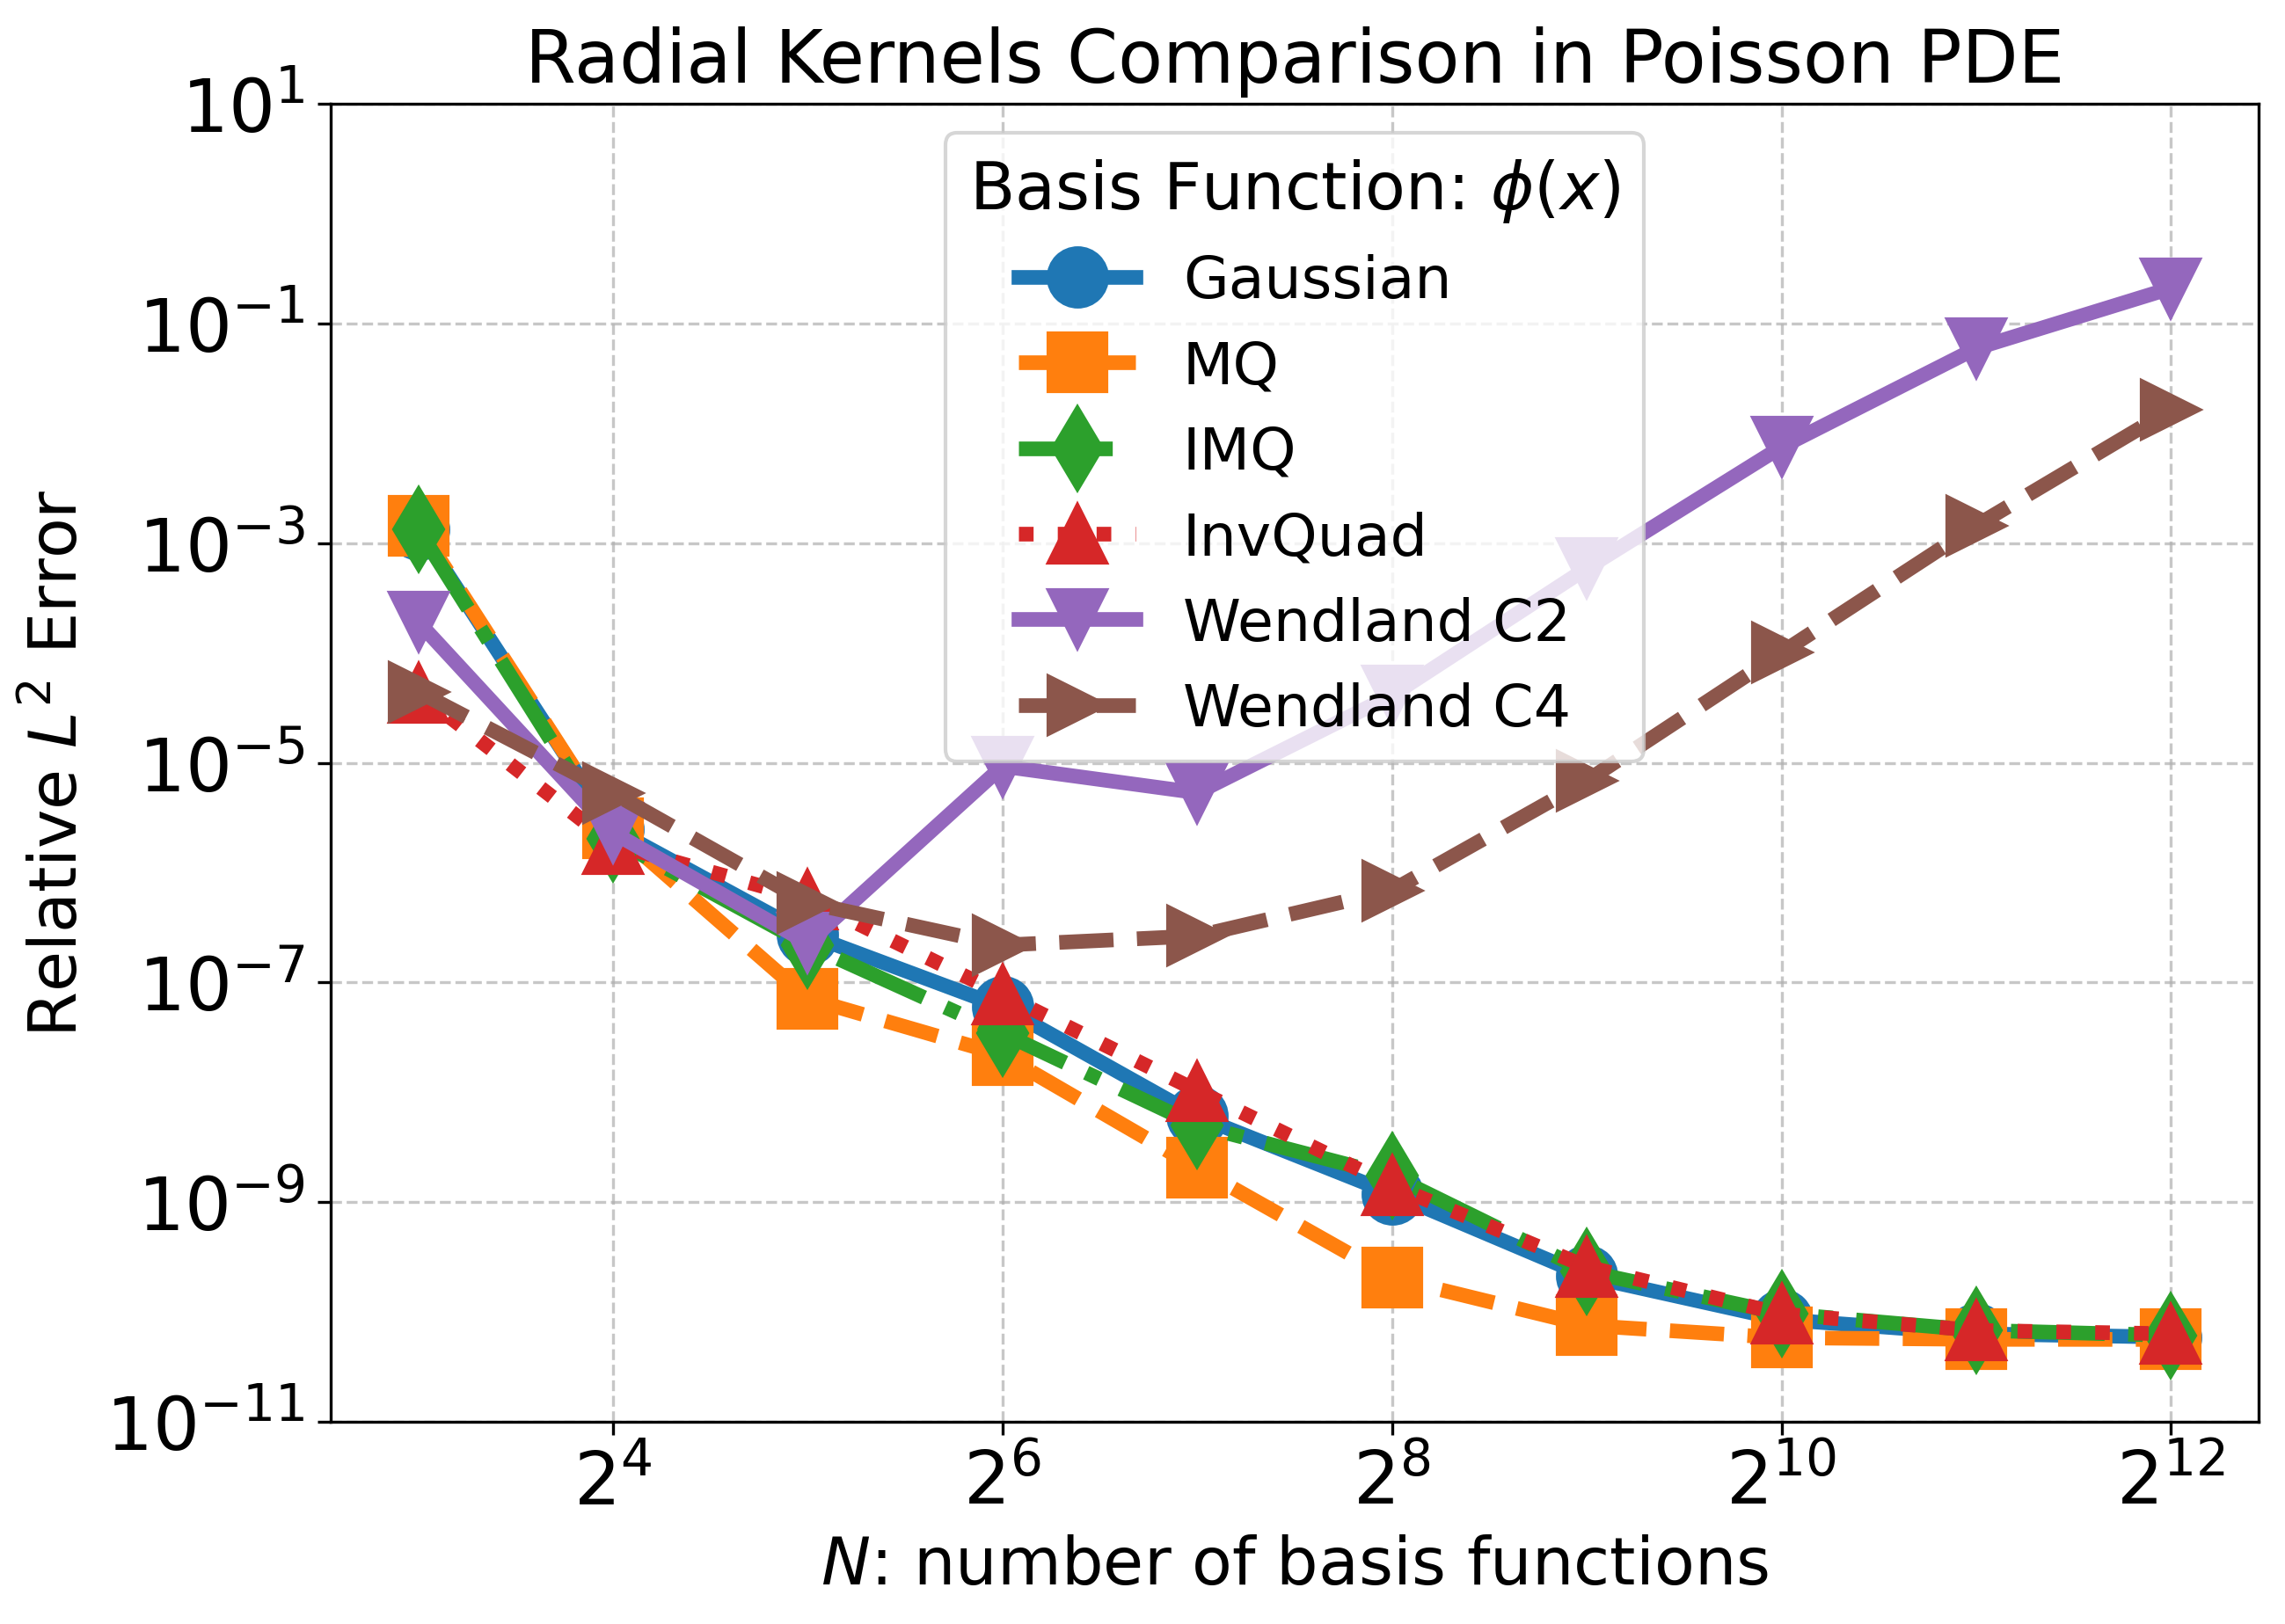

In [3]:
from itertools import cycle
# --- Single plot: RBF type comparison ---

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(9, 6.5), dpi = 300)

markers_cycle = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyles = ['-', '--', '-.', ':']  # will cycle if there are >4 series

for i, (name, errs) in enumerate(errors_rbf.items()):
    ax.plot(
        N_values,
        errs,
        linestyle=linestyles[i % len(linestyles)],
        marker=next(markers_cycle),
        linewidth=4.0,
        label=name
    )


ax.set_xscale('log', base = 2)
ax.set_yscale('log')
ax.set_ylim(1e-11, 1e1)
ax.set_title(r'Radial Kernels Comparison in Poisson PDE')
ax.set_xlabel(r'$N$: number of basis functions')
ax.set_ylabel(r'Relative $L^2$ Error')
ax.tick_params(labelsize=20)
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(title = f'Basis Function: $\phi(x)$',fontsize=16, title_fontsize = 18)

plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig3_poisson.png', dpi=300, bbox_inches='tight')


# Benchmark $\beta$ in Poisson PDE

# T = 4.0

In [ ]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 4.0
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=12)  # 1e1 ... 1e10 (10 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq = solver_rbf( N = N, rbf_func = rbf_gaussian, drbf_func = drbf_gaussian, tau=tau, beta=beta, T = T)
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

In [ ]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_ylim(1e-12, 1e1)
ax.set_title(rf"$\beta$ in Poisson: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings", fontsize=18, title_fontsize = 18)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig13_poisson.png', dpi = 300)


# T = 8.0 

In [6]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 8.0
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=12)  # 1e1 ... 1e10 (10 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq = solver_rbf( N = N, rbf_func = rbf_gaussian, drbf_func = drbf_gaussian, tau=tau, beta=beta, T = T)
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

        beta         N=256         N=512        N=1024        N=2048
   1.000e+01     5.050e-02     5.050e-02     5.050e-02     5.050e-02
   6.579e+01     1.168e-03     1.168e-03     1.168e-03     1.168e-03
   4.329e+02     2.704e-05     2.702e-05     2.700e-05     2.699e-05
   2.848e+03     6.331e-07     6.269e-07     6.252e-07     6.244e-07
   1.874e+04     1.642e-08     1.495e-08     1.464e-08     1.452e-08
   1.233e+05     1.609e-09     5.594e-10     3.764e-10     3.479e-10
   8.111e+05     8.414e-10     1.512e-10     2.912e-11     1.144e-11
   5.337e+06     7.433e-10     1.125e-10     1.509e-11     2.338e-12
   3.511e+07     6.007e-10     9.314e-11     1.263e-11     1.782e-12
   2.310e+08     5.848e-10     8.341e-11     1.318e-11     1.814e-12
   1.520e+09     7.028e-10     1.066e-10     1.818e-11     4.685e-12
   1.000e+10     3.502e-09     2.260e-10     5.915e-11     1.721e-11


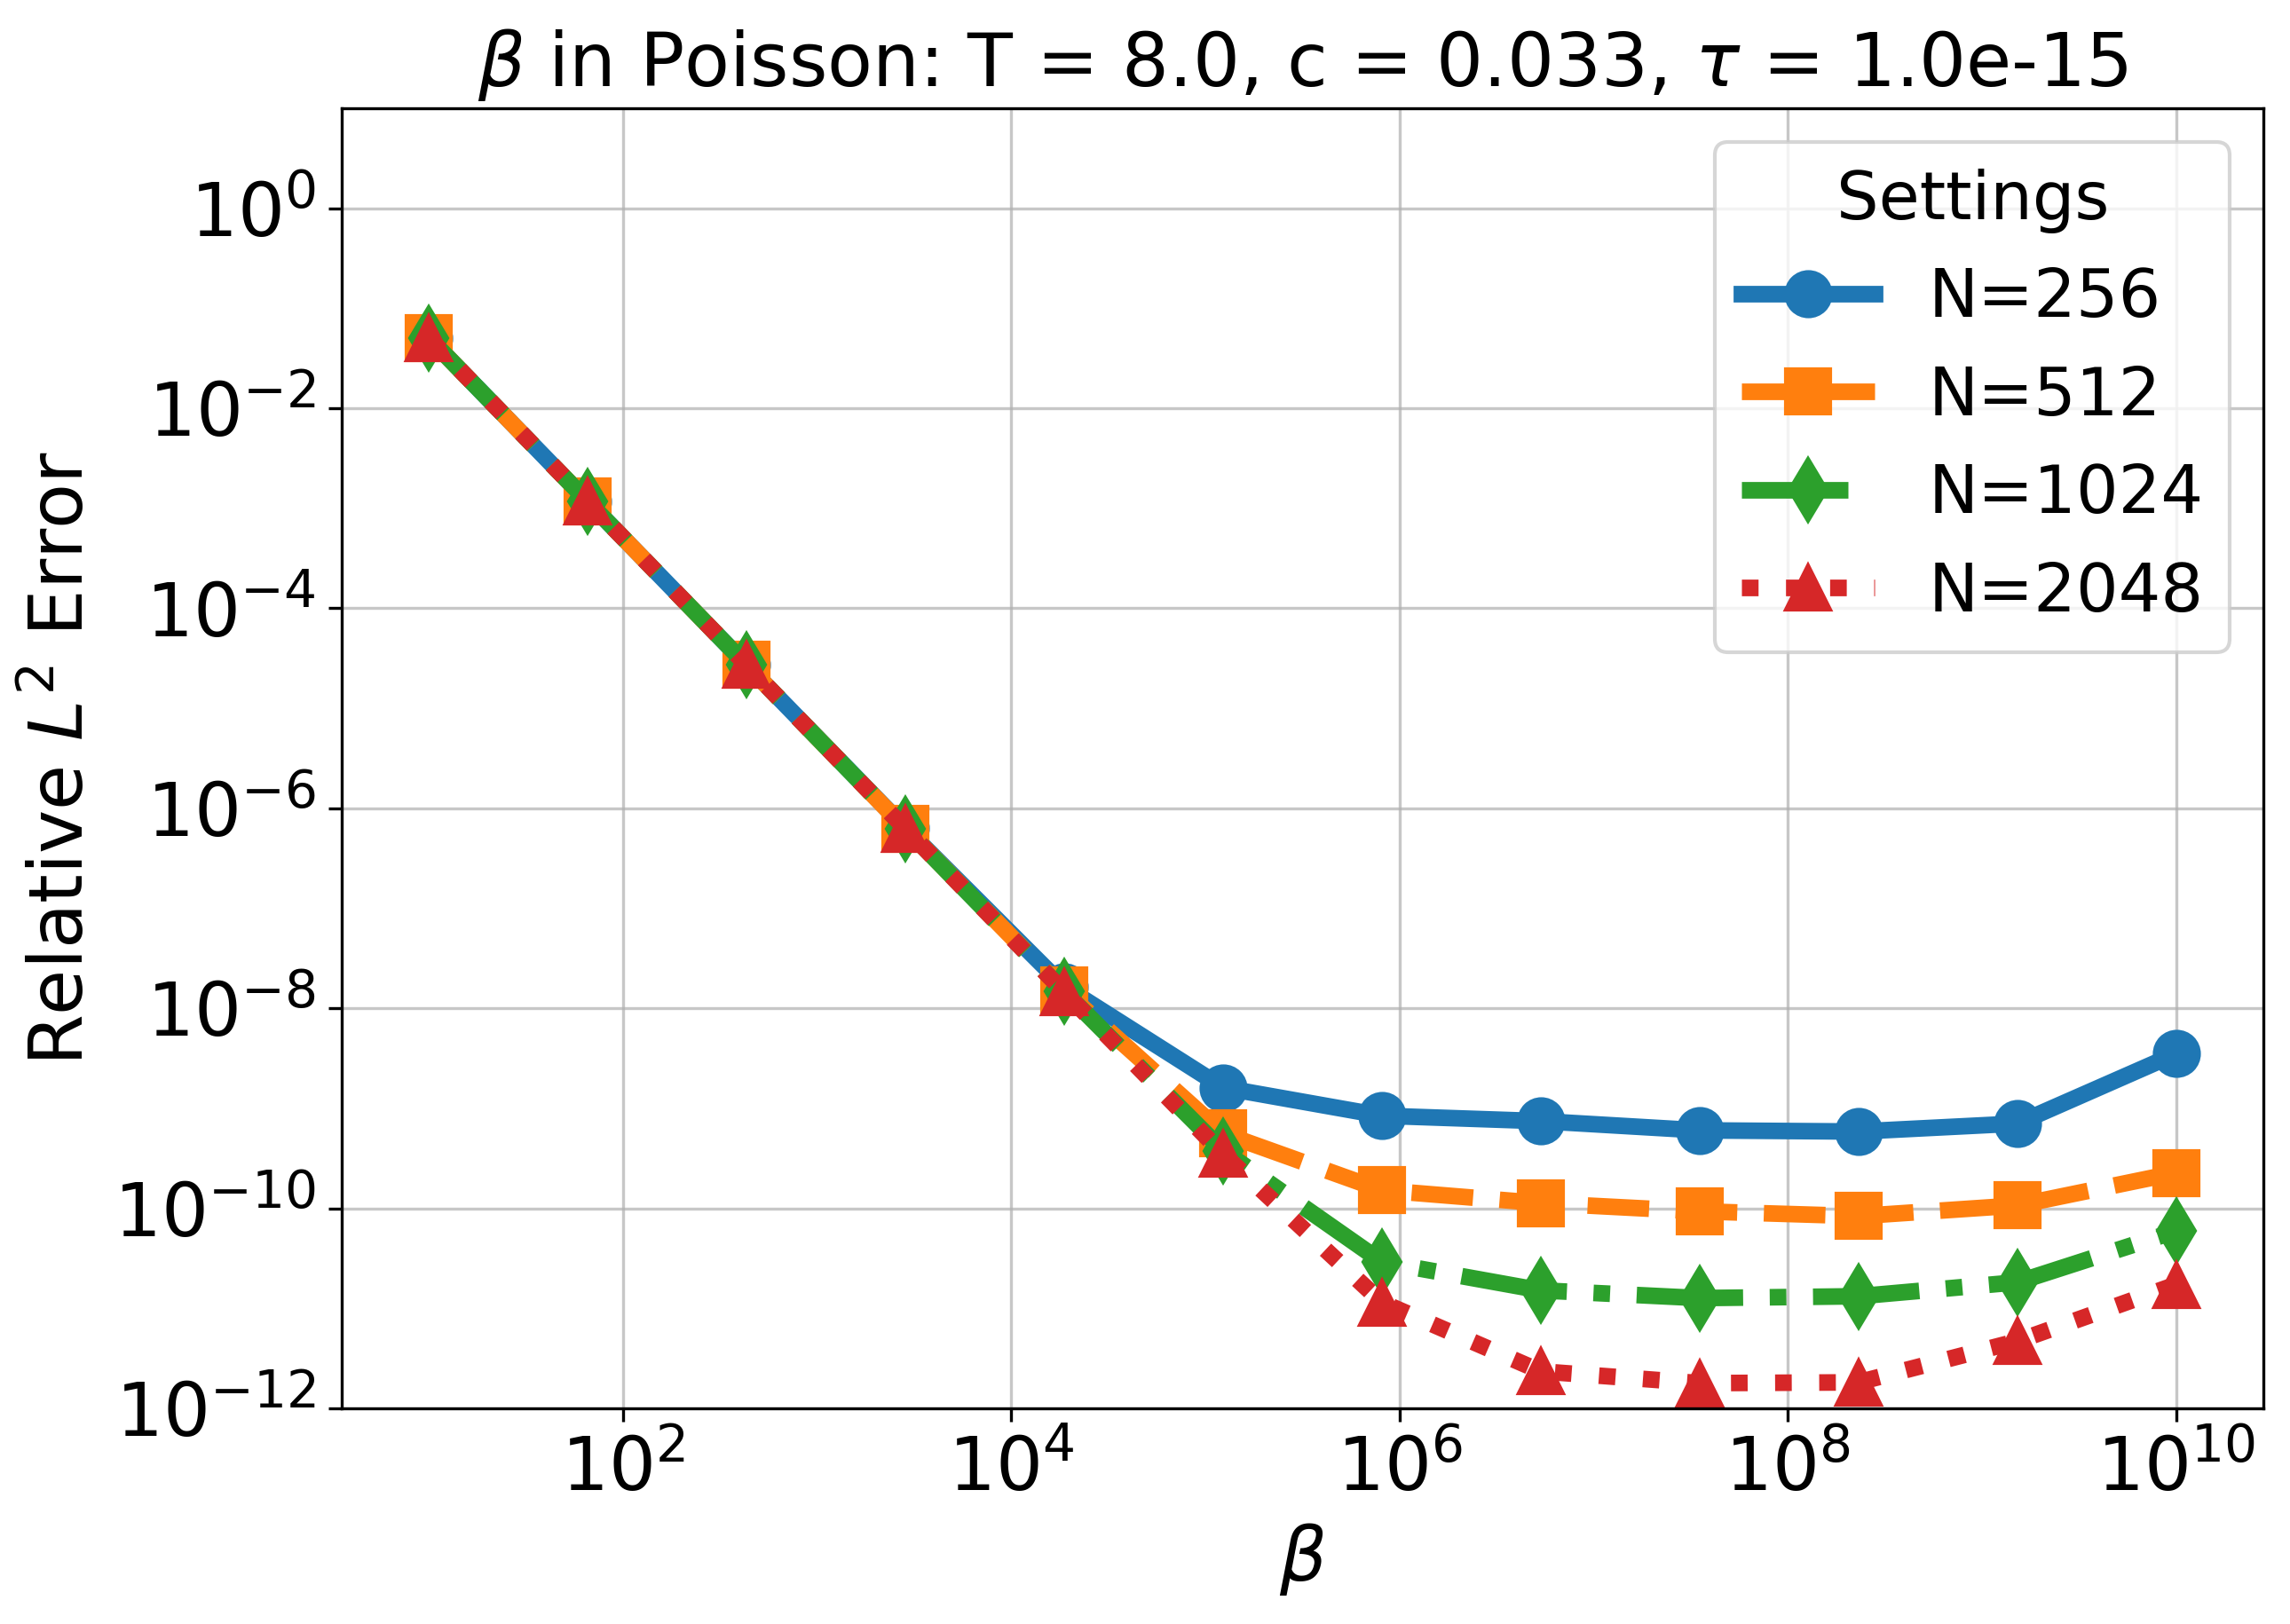

In [8]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_ylim(1e-12, 1e1)
ax.set_title(rf"$\beta$ in Poisson: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings", fontsize=18, title_fontsize = 18)
plt.tight_layout()
plt.savefig('./Outputs/1D_Poisson/fig14_poisson.png', dpi = 300)
